In [436]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.ticker import MultipleLocator
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
# 读取数据，设置指定列的类型
df1 = pd.read_csv(r"F:\codes\00-WORK\work-1\01-myself\01-predict\02-blind\EXCEL\ADlog_填充.csv",  dtype={'DIPOCE': str, 'BA_Code': str, 'Cata_Code': str})
df1

,DIPOCE,DI_NCO,PO_HV,PO_f,BA_Code,BA_Mn,PO_Phr,BA_Phr,FS_Phr,Cata_Phr,...,M_loss,Yield,R,CHS,A_Mix_t,AB_Mix_t,Q,Cata_Code,MCS,AD(kg/m3)
0,110100000,31.0,367.991736,4.464132,1000,18.0,67.567568,2.182432,1.013514,1.013514,...,5.351351,96.884711,1.83,59.700000,81.11,5.3,0.0,100000,108.6000,36.8
1,110100000,31.0,367.991736,4.464132,1000,18.0,67.567568,2.182432,1.013514,1.013514,...,5.351351,96.884711,1.83,59.700000,81.11,5.3,0.0,100000,94.1000,36.8
2,100010000,31.5,440.000000,3.158698,1000,18.0,50.676157,1.494662,1.010676,0.455516,...,5.229893,97.017857,1.10,58.400000,120.00,10.0,0.0,100100,310.0000,39.0
3,100100100,31.5,429.326712,3.370281,1000,18.0,32.931727,0.975330,0.659782,0.295468,...,4.215720,97.377587,1.10,63.500000,120.00,10.0,0.0,100100,220.0000,37.6
4,100100100,31.5,418.118624,3.432704,1000,18.0,30.906059,0.990550,0.617009,0.278488,...,4.084491,97.428971,1.10,64.600000,120.00,10.0,0.0,100100,210.0000,30.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
288,100010000,31.0,416.000000,2.000000,1000,18.0,73.421439,2.276065,1.101322,0.367107,...,5.563713,96.859603,1.10,57.662997,103.59,5.0,48.0,100000,219.2185,37.8
289,100010000,31.0,416.000000,2.000000,1000,18.0,80.515298,1.328502,1.207729,0.402576,...,3.247450,98.229830,1.10,55.396967,125.04,5.0,48.0,100000,217.1510,58.0
290,100010000,31.0,416.000000,2.000000,1000,18.0,84.104289,0.849453,1.261564,0.420521,...,2.076441,98.887437,1.10,54.317040,119.34,5.0,48.0,100000,211.3560,81.3
291,100010000,31.0,416.000000,2.000000,1000,18.0,85.251492,0.699062,1.278772,0.426257,...,1.708819,99.089386,1.10,53.980672,117.65,5.0,48.0,100000,202.5670,97.6


In [438]:
df2 = pd.read_csv(r"F:\codes\00-WORK\work-1\01-myself\01-predict\02-blend\EXCEL\AD.csv",  dtype={'DIPOCE': str, 'BA_Code': str, 'Cata_Code': str})
df2.dropna(subset=['AD(kg/m3)'], how='any', inplace=True) 

df2


,DIPOCE,DI_NCO,PO_HV,PO_f,BA_Code,BA_Mn,PO_Phr,BA_Phr,FS_Phr,Cata_Phr,...,M_loss,Yield,R,CHS,A_Mix_t,AB_Mix_t,Q,Cata_Code,MCS,AD(kg/m3)
0,100100000,31.25,410.000000,4.438890,1000,18.00,105.263158,1.052632,5.263158,0.736842,...,2.464000,98.778384,0.900000,48.700000,128.2342,15.0000,480.0,10000,300.839745,82.30
1,100100000,31.25,410.000000,4.430268,1000,18.00,100.000000,1.000000,5.000000,0.700000,...,2.464000,98.807934,0.950000,50.000000,125.2283,15.0000,480.0,10000,303.314815,77.90
2,100100000,31.25,410.000000,4.367690,1000,18.00,94.339623,0.943396,4.716981,0.660377,...,2.464000,98.841561,1.000000,51.500000,122.3211,15.0000,480.0,10000,297.745460,75.30
3,100100000,31.25,410.000000,4.346416,1000,18.00,90.090090,0.900901,4.504505,0.630631,...,2.464000,98.868167,1.050000,52.600000,124.2825,15.0000,480.0,10000,288.772650,69.00
4,100100000,31.25,410.000000,4.288976,1000,18.00,86.206897,0.862069,4.310345,0.603448,...,2.464000,98.893579,1.100000,53.700000,126.3068,15.0000,480.0,10000,278.238315,59.40
5,100100000,31.25,410.000000,4.305843,1000,18.00,93.457944,0.467290,4.672897,0.654206,...,1.232000,99.422139,1.050000,51.700000,122.2186,15.0000,480.0,10000,297.540175,85.00
6,100100000,31.25,410.000000,4.346416,1000,18.00,90.090090,0.900901,4.504505,0.630631,...,2.464000,98.868167,1.050000,52.600000,124.2825,15.0000,480.0,10000,288.772650,69.00
7,100100000,31.25,410.000000,4.327919,1000,18.00,86.956522,1.304348,4.347826,0.608696,...,3.652000,98.356436,1.050000,53.500000,126.6373,15.0000,480.0,10000,281.558290,63.00
8,100100000,31.25,410.000000,4.350361,1000,18.00,84.033613,1.680672,4.201681,0.588235,...,4.840000,97.865020,1.050000,54.300000,122.6426,15.0000,480.0,10000,293.547145,60.00
9,100100000,31.25,410.000000,4.373105,1000,18.00,81.300813,2.032520,4.065041,0.569106,...,6.160000,97.335640,1.050000,55.200000,123.1030,15.0000,480.0,10000,303.714755,50.00


In [439]:
pad_lengths = {
    'DIPOCE': 10,    # 9位
    'BA_Code': 4,   # 4位
    'Cata_Code': 6  # 6位
}

for col, length in pad_lengths.items():
    df1[col] = df1[col].astype(str).str.zfill(length)

pad_lengths = {
    'DIPOCE': 10,    # 9位
    'BA_Code': 4,   # 4位
    'Cata_Code': 6  # 6位
}

for col, length in pad_lengths.items():
    df2[col] = df2[col].astype(str).str.zfill(length)


In [440]:
# 假设标签列叫做 'target'
X_train = df1.drop(columns=['AD(kg/m3)'])
y_train = np.log10(df1['AD(kg/m3)'])

X_test = df2.drop(columns=['AD(kg/m3)'])
y_test = np.log10(df2['AD(kg/m3)'])

In [441]:
# # 假设标签列叫做 'target'
# X_train = df1.drop(columns=['AD(kg/m3)'])
# y_train = df1['AD(kg/m3)']

# X_test = df2.drop(columns=['AD(kg/m3)'])
# y_test = df2['AD(kg/m3)']


In [442]:
ratio_count = len(y_test) / len(y_train)
print("y_test / y_train :", ratio_count*100)


y_test / y_train : 7.849829351535837


In [443]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.spatial.distance import jensenshannon
from scipy import stats

# 计算核密度估计
kde_train = gaussian_kde(y_train)
kde_test = gaussian_kde(y_test)

# 在相同的点上计算概率密度
x_range = np.linspace(min(y_train.min(), y_test.min()), max(y_train.max(), y_test.max()), 100)
hist_train_smooth = kde_train(x_range)
hist_test_smooth = kde_test(x_range)

# 重新计算 JS 散度
js_divergence_smooth = jensenshannon(hist_train_smooth, hist_test_smooth)
print(f"平滑后 Jensen-Shannon 散度: {js_divergence_smooth}")


平滑后 Jensen-Shannon 散度: 0.3013947623856747


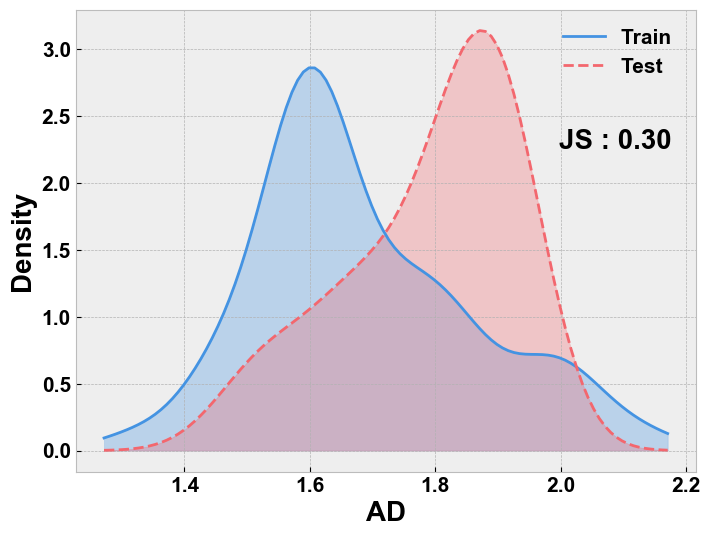

In [444]:
# 绘制平滑后的分布
plt.figure(figsize=(8, 6))
plt.plot(x_range, hist_train_smooth, label='Train ', color="#4493E2", linestyle='-', linewidth=2)
plt.plot(x_range, hist_test_smooth, label='Test ', color="#F3676E", linestyle='--', linewidth=2)
plt.fill_between(x_range, hist_train_smooth, alpha=0.3, color='#4493E2')
plt.fill_between(x_range, hist_test_smooth, alpha=0.3, color="#F3676E")

plt.text(0.78, 0.7, f"JS : {js_divergence_smooth:.2f}", fontsize=20, transform=plt.gca().transAxes)

# 设置标签和其他参数
plt.xlabel("AD", weight='bold', fontsize=20)
plt.ylabel("Density", weight='bold', fontsize=20)
plt.legend(fontsize=15, frameon=False)
plt.grid(True)

# 设置背景透明
plt.gcf().patch.set_alpha(0)  # 设置图表背景透明

# 显示图形
plt.show()

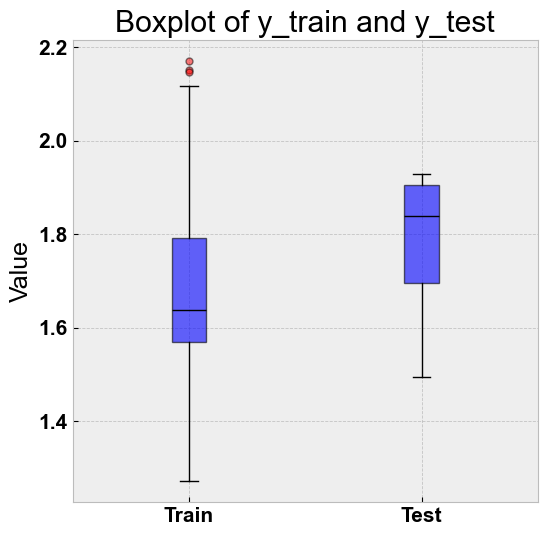

In [445]:
# 颜色定义
train_color = 'blue'
test_color = 'red'

# 创建图形
plt.figure(figsize=(6, 6))

# 绘制箱线图
plt.boxplot([y_train, y_test], vert=True, patch_artist=True, 
            boxprops=dict(facecolor=train_color, alpha=0.6), 
            medianprops=dict(color='black'), 
            whiskerprops=dict(color='black'), 
            capprops=dict(color='black'), 
            flierprops=dict(marker='o', markersize=5, markerfacecolor='red', alpha=0.5))

# 设置 x 轴刻度
plt.xticks([1, 2], ["Train", "Test"])

# 添加标题和坐标轴标签
plt.title("Boxplot of y_train and y_test")
plt.ylabel("Value")

# 添加网格
plt.grid(True, linestyle="--", linewidth=0.6, alpha=0.7)

# 显示图像
plt.show()

In [446]:
params = {'iterations':1400,
            'depth': 6,
            'learning_rate': 0.012,
            'l2_leaf_reg': 2.8,
            'bagging_temperature': 0.43,
            'border_count': 178,
      }

In [447]:
model = CatBoostRegressor(**params, verbose=0, random_state=42)

model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# 计算 R²
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

# 计算 MAE
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

# 计算 MSE
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

# 计算 RMSE
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

# 输出结果
print(f"Train R²: {train_r2:.4f}, Test R²: {test_r2:.4f}")
print(f"Train MAE: {train_mae:.4f}, Test MAE: {test_mae:.4f}")
print(f"Train MSE: {train_mse:.4f}, Test MSE: {test_mse:.4f}")
print(f"Train RMSE: {train_rmse:.4f}, Test RMSE: {test_rmse:.4f}")



Train R²: 0.9877, Test R²: 0.7834
Train MAE: 0.0150, Test MAE: 0.0516
Train MSE: 0.0004, Test MSE: 0.0037
Train RMSE: 0.0194, Test RMSE: 0.0607


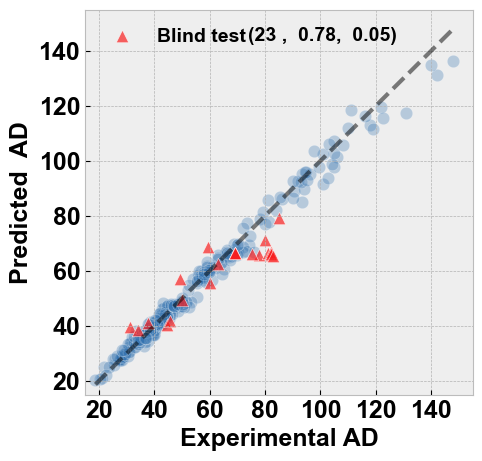

In [448]:
plt.style.use('bmh')
plt.rc('font', weight='bold')
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 15
plt.rcParams['text.color'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'
# 创建图形和轴
fig, ax = plt.subplots(figsize=(5, 5))
# 绘制训练集和测试集散点图
ax.scatter(10**y_train, 10**y_train_pred, alpha=0.3, c="#3574B1",
            edgecolors='white', s=80, marker='o', label='')
ax.scatter(10**y_test, 10**y_test_pred, alpha=0.7, c="#F81F1F", 
           edgecolors='white', s=80, marker='^', label='Blind test')

# 添加对角线及偏移线
ax.plot([10**y_train.min(), 10**y_train.max()], [10**y_train.min(), 10**y_train.max()], 'k--', lw=3, alpha=0.5)
sigma = np.std(10**y_test)
# offset = 1.0 * sigma
# ax.plot([10**y_train.min(), 10**y_train.max()], [10**y_train.min() + offset, 10**y_train.max() + offset], 'k--', lw=3, alpha=0.5)
# ax.plot([10**y_train.min(), 10**y_train.max()], [10**y_train.min() - offset, 10**y_train.max() - offset], 'k--', lw=3, alpha=0.5)
# 统计样本数
train_samples = len(y_train)
test_samples = len(y_test)

# 添加文本信息（R², MAE）
# ax.text(0.27, 0.93, f'({train_samples},  %.2f,  %.2f)' % (model.score(X_train, y_train), train_mae), fontsize=12, transform=ax.transAxes)
ax.text(0.42, 0.92, f'({test_samples} ,  %.2f,  %.2f)' % (model.score(X_test, y_test), test_mae), fontsize=14, transform=ax.transAxes)

# 设置坐标轴范围
ax.set_xlim([15, 155])
ax.set_ylim([15, 155])

# 设置坐标轴刻度
ax.xaxis.set_major_locator(MultipleLocator(20))
ax.yaxis.set_major_locator(MultipleLocator(20))

# 设置坐标轴标签
ax.set_xlabel(r'Experimental AD', weight='bold', fontsize=18)
ax.set_ylabel(r'Predicted  AD', weight='bold', fontsize=18)
ax.tick_params(axis='both', labelsize=18)

# 添加图例并去掉边框
ax.legend(loc='upper left', fontsize=14, frameon=False)

plt.savefig("AD.tiff", dpi=600, bbox_inches='tight')
# 显示图像
plt.show()